# THỰC HÀNH 2.1: CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY (Decision Tree & Random Forest)


**Dữ liệu:** [Default of Credit Card Clients](https://www.kaggle.com/datasets/deceneu/default-of-credit-card-clients) – file `UCI_Credit_Card.csv`

**Mục tiêu:**
- Xây dựng cây quyết định bằng `DecisionTreeClassifier` và trực quan hóa cây.
- Dùng `GridSearchCV` tìm siêu tham số tối ưu (`max_depth`, `n_estimators`).
- Xây dựng Random Forest, đánh giá mô hình và phân tích tầm quan trọng của đặc trưng.

## 0. Ôn tập lý thuyết

| Khái niệm | Tóm tắt |
|---|---|
| **CRISP-DM** | Quy trình khai phá dữ liệu 6 bước: Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment. |
| **SEMMA** | Quy trình của SAS: Sample → Explore → Modify → Model → Assess. |
| **Cây quyết định** | Mô hình dạng cây: *nút gốc* chứa toàn bộ dữ liệu, *nút trong* kiểm tra một đặc trưng, *nhánh* là kết quả kiểm tra, *nút lá* chứa nhãn dự đoán. |
| **Gini / Entropy** | Tiêu chí chọn điểm tách: Gini = 1 − Σpᵢ²; Entropy = −Σpᵢ·log₂pᵢ; Information Gain = Entropy(cha) − Σ(trọng số · Entropy(con)). Gini tính nhanh hơn, Entropy nhạy hơn với phân bố lớp. |
| **Random Forest** | Tập hợp nhiều cây được huấn luyện trên các mẫu bootstrap và tập con đặc trưng ngẫu nhiên, dự đoán bằng bỏ phiếu → giảm phương sai, ít quá khớp hơn cây đơn. |
| **Hạn chế cây đơn** | Dễ quá khớp khi cây sâu, nhạy với thay đổi nhỏ của dữ liệu, ranh giới quyết định song song trục. |

## 1. Nạp thư viện và cấu hình

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import GridSearchCV, train_test_split

%matplotlib inline
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

DATA_PATH = "data/UCI_Credit_Card.csv"
TARGET = "default payment next month"
OUT_DIR = Path("ket_qua/1_DT&RF")
OUT_DIR.mkdir(exist_ok=True)

## 2. Nạp dữ liệu, làm sạch và chọn đặc trưng

- `EDUCATION` có các giá trị 0, 5, 6 không có trong mô tả → gộp vào nhóm 4 (others). `MARRIAGE` = 0 → gộp vào nhóm 3.
- Loại các cột không dùng: `ID`, `SEX`, `PAY_2`…`PAY_6`.

In [2]:
df = pd.read_csv(DATA_PATH)
print("Kích thước ban đầu:", df.shape)
df.head()

Kích thước ban đầu: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df = df.rename(columns={"PAY_0": "PAY_1", "default.payment.next.month": TARGET})
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

items_to_remove = ["ID", "SEX", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
                   "EDUCATION_CAT", "graduate school", "high school",
                   "none", "others", "university"]
features = [c for c in df.columns if c not in items_to_remove and c != TARGET]

print("Số đặc trưng:", len(features))
print(features)
print("\nGiá trị thiếu:", int(df[features].isna().sum().sum()))
print(f"Tỉ lệ vỡ nợ (lớp 1): {df[TARGET].mean():.3f}")

Số đặc trưng: 17
['LIMIT_BAL', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Giá trị thiếu: 0
Tỉ lệ vỡ nợ (lớp 1): 0.221


**Phân bố nhãn** (dữ liệu mất cân bằng → nên dùng ROC AUC thay vì chỉ accuracy):

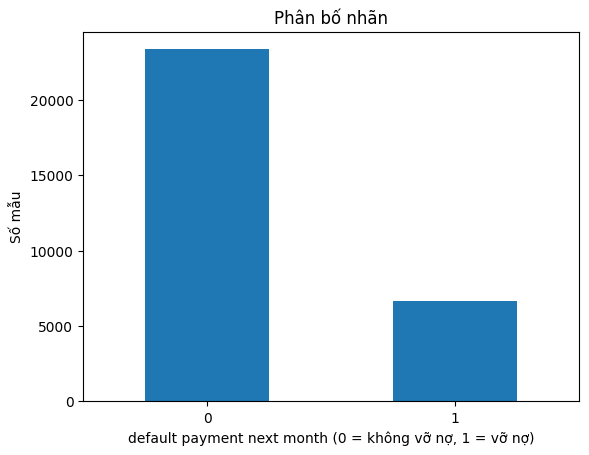

In [4]:
df[TARGET].value_counts().plot.bar(rot=0)
plt.xlabel("default payment next month (0 = không vỡ nợ, 1 = vỡ nợ)")
plt.ylabel("Số mẫu")
plt.title("Phân bố nhãn")
plt.show()

## 3. Chia tập train / test (80% / 20%)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features].values, df[TARGET].values,
    test_size=0.2, random_state=24)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (24000, 17) | Test: (6000, 17)


Hàm hỗ trợ in các chỉ số đánh giá trên tập test (dùng lại nhiều lần):

In [6]:
def danh_gia(ten, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"--- Đánh giá {ten} trên tập TEST ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred,
                                target_names=["Not defaulted", "Defaulted"]))

## Nhiệm vụ 1: Xây dựng cây quyết định (`max_depth=2`)

In [7]:
dt = tree.DecisionTreeClassifier(max_depth=2, random_state=24)
dt.fit(X_train, y_train)
danh_gia("Decision Tree (depth=2)", dt, X_test, y_test)

--- Đánh giá Decision Tree (depth=2) trên tập TEST ---
Accuracy : 0.8178
ROC AUC  : 0.7028
Confusion matrix:
 [[4470  173]
 [ 920  437]]
               precision    recall  f1-score   support

Not defaulted       0.83      0.96      0.89      4643
    Defaulted       0.72      0.32      0.44      1357

     accuracy                           0.82      6000
    macro avg       0.77      0.64      0.67      6000
 weighted avg       0.80      0.82      0.79      6000



**Hiển thị cây** bằng `plot_tree`:

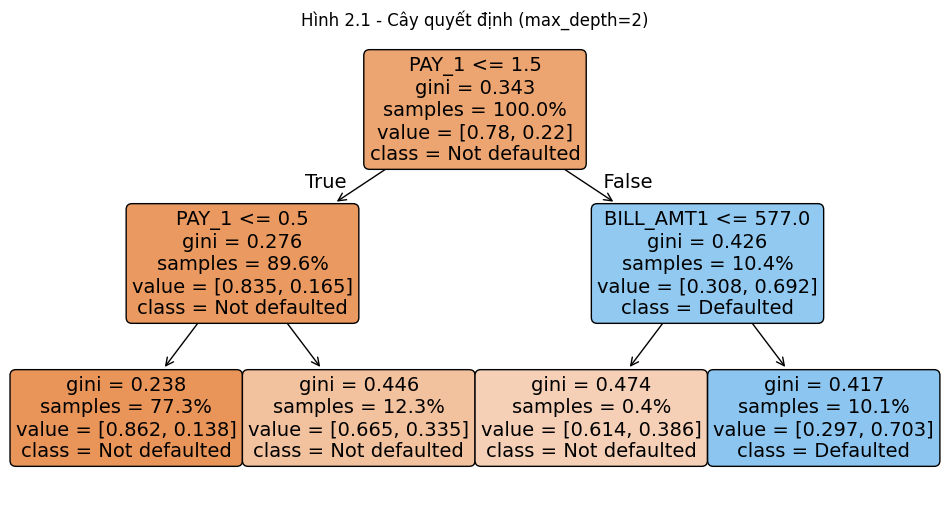

In [8]:
plt.figure(figsize=(12, 6))
tree.plot_tree(dt, feature_names=features, filled=True, rounded=True,
               proportion=True, class_names=["Not defaulted", "Defaulted"])
plt.title("Hình 2.1 - Cây quyết định (max_depth=2)")
plt.savefig(OUT_DIR / "hinh_2_1_cay_quyet_dinh.png", bbox_inches="tight")
plt.show()

## Nhiệm vụ 2: Tìm `max_depth` tối ưu bằng `GridSearchCV`

- `scoring='roc_auc'`: chọn mô hình theo diện tích dưới đường ROC.
- `cv=4`: kiểm tra chéo 4 phần (4-fold cross-validation).
- `return_train_score=True`: lưu điểm trên tập train để so sánh với tập validation → phát hiện **quá khớp** (bias/variance).

In [9]:
params = {"max_depth": [1, 2, 4, 6, 8, 10, 12]}
dt = tree.DecisionTreeClassifier(random_state=24)
cv = GridSearchCV(dt, param_grid=params, scoring="roc_auc",
                  n_jobs=-1, refit=True, cv=4, verbose=1,
                  error_score=np.nan, return_train_score=True)
cv.fit(X_train, y_train)

print("Tham số tốt nhất:", cv.best_params_)
print(f"ROC AUC (CV) tốt nhất: {cv.best_score_:.4f}")

Fitting 4 folds for each of 7 candidates, totalling 28 fits
Tham số tốt nhất: {'max_depth': 6}
ROC AUC (CV) tốt nhất: 0.7438


In [10]:
cv_results_df = pd.DataFrame(cv.cv_results_)
cv_results_df["param_max_depth"] = cv_results_df["param_max_depth"].astype(int)
cv_results_df[["param_max_depth", "mean_train_score", "mean_test_score",
               "std_train_score", "std_test_score"]].round(4)

,param_max_depth,mean_train_score,mean_test_score,std_train_score,std_test_score
0,1,0.6435,0.6435,0.0010,0.0029
1,2,0.6986,0.6985,0.0019,0.0059
2,4,0.7506,0.7406,0.0020,0.0032
3,6,0.7761,0.7438,0.0015,0.0078
4,8,0.8037,0.7290,0.0018,0.0037
5,10,0.8404,0.7109,0.0021,0.0068
6,12,0.8844,0.6747,0.0040,0.0093


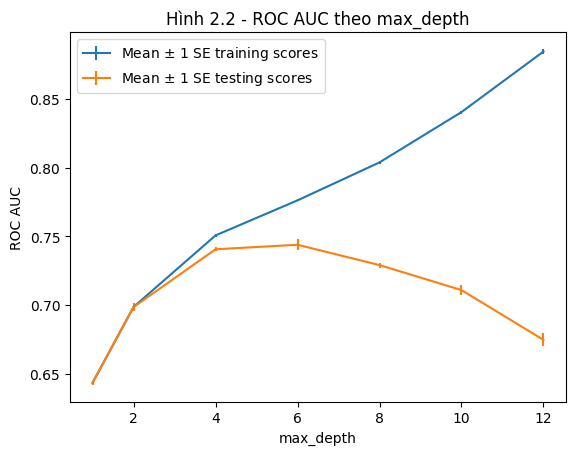

In [11]:
ax = plt.axes()
ax.errorbar(cv_results_df["param_max_depth"], cv_results_df["mean_train_score"],
            yerr=cv_results_df["std_train_score"] / np.sqrt(4),
            label=r"Mean $\pm$ 1 SE training scores")
ax.errorbar(cv_results_df["param_max_depth"], cv_results_df["mean_test_score"],
            yerr=cv_results_df["std_test_score"] / np.sqrt(4),
            label=r"Mean $\pm$ 1 SE testing scores")
ax.legend()
plt.xlabel("max_depth")
plt.ylabel("ROC AUC")
plt.title("Hình 2.2 - ROC AUC theo max_depth")
plt.savefig(OUT_DIR / "hinh_2_2_max_depth.png", bbox_inches="tight")
plt.show()

In [12]:
danh_gia("Decision Tree (best)", cv.best_estimator_, X_test, y_test)

--- Đánh giá Decision Tree (best) trên tập TEST ---
Accuracy : 0.8163
ROC AUC  : 0.7500
Confusion matrix:
 [[4444  199]
 [ 903  454]]
               precision    recall  f1-score   support

Not defaulted       0.83      0.96      0.89      4643
    Defaulted       0.70      0.33      0.45      1357

     accuracy                           0.82      6000
    macro avg       0.76      0.65      0.67      6000
 weighted avg       0.80      0.82      0.79      6000



## Nhiệm vụ 3: Xây dựng rừng cây (Random Forest)

Tìm số cây `n_estimators` từ 10 đến 100 (bước 10).

In [13]:
rf = RandomForestClassifier(
    n_estimators=10, criterion="gini", max_depth=3,
    min_samples_split=2, min_samples_leaf=1, max_features="sqrt",
    bootstrap=True, oob_score=False, n_jobs=-1, random_state=4)

rf_params_ex = {"n_estimators": list(range(10, 110, 10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex, scoring="roc_auc",
                        n_jobs=None, refit=True, cv=4, verbose=1,
                        error_score=np.nan,   
                        return_train_score=True)
cv_rf_ex.fit(X_train, y_train)
print("Tham số tốt nhất:", cv_rf_ex.best_params_)

Fitting 4 folds for each of 10 candidates, totalling 40 fits
Tham số tốt nhất: {'n_estimators': 60}


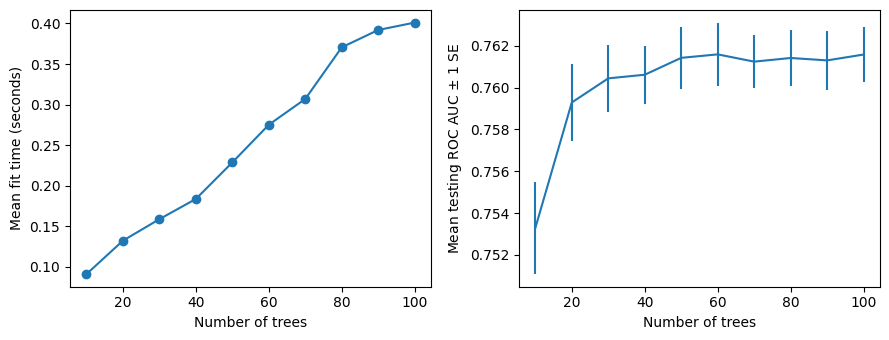

In [14]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
cv_rf_ex_results_df["param_n_estimators"] = cv_rf_ex_results_df["param_n_estimators"].astype(int)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 3.5))
axs[0].plot(cv_rf_ex_results_df["param_n_estimators"],
            cv_rf_ex_results_df["mean_fit_time"], "-o")
axs[0].set_xlabel("Number of trees")
axs[0].set_ylabel("Mean fit time (seconds)")
axs[1].errorbar(cv_rf_ex_results_df["param_n_estimators"],
                cv_rf_ex_results_df["mean_test_score"],
                yerr=cv_rf_ex_results_df["std_test_score"] / np.sqrt(4))
axs[1].set_xlabel("Number of trees")
axs[1].set_ylabel(r"Mean testing ROC AUC $\pm$ 1 SE")
plt.tight_layout()
plt.savefig(OUT_DIR / "hinh_2_3_so_cay.png", bbox_inches="tight")
plt.show()

**Mức độ quan trọng của các đặc trưng** (mô hình tốt nhất):

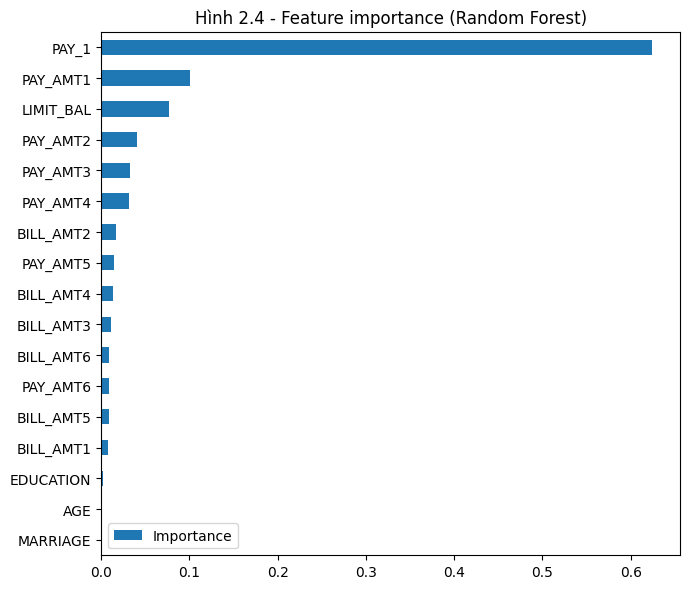

,Importance
PAY_1,0.624681
PAY_AMT1,0.100108
LIMIT_BAL,0.077335
PAY_AMT2,0.040162
PAY_AMT3,0.032703


In [15]:
feat_imp_df = pd.DataFrame(
    {"Importance": cv_rf_ex.best_estimator_.feature_importances_},
    index=features).sort_values("Importance", ascending=True)

feat_imp_df.plot.barh(figsize=(7, 6))
plt.title("Hình 2.4 - Feature importance (Random Forest)")
plt.tight_layout()
plt.savefig(OUT_DIR / "hinh_2_4_feature_importance.png", bbox_inches="tight")
plt.show()

feat_imp_df.sort_values("Importance", ascending=False).head(5)

In [16]:
danh_gia("Random Forest (best)", cv_rf_ex.best_estimator_, X_test, y_test)

--- Đánh giá Random Forest (best) trên tập TEST ---
Accuracy : 0.8102
ROC AUC  : 0.7659
Confusion matrix:
 [[4502  141]
 [ 998  359]]
               precision    recall  f1-score   support

Not defaulted       0.82      0.97      0.89      4643
    Defaulted       0.72      0.26      0.39      1357

     accuracy                           0.81      6000
    macro avg       0.77      0.62      0.64      6000
 weighted avg       0.80      0.81      0.77      6000

